In [66]:
from utils.random_forest_utils.rf_preprocessing_utils import WindowAlgPreprocessor

rf_preprocessor = WindowAlgPreprocessor(sensors_path="../../../../data/ml/features.csv", target_path="../../../../data/ml/targets.csv")
sensors_df, target_df = rf_preprocessor.read_data()
sensors_df = rf_preprocessor.feature_selection()
rf_preprocessor.normalize_angle()

,Experiment_ID,Angle[degree]ORDistance[mm],Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm]
0,2,0.000000,0.317461,0.337050,0.626034,0.344543
1,2,0.022036,0.319825,0.363018,0.600159,0.372211
2,2,0.044072,0.319035,0.401244,0.560835,0.412939
3,2,0.066108,0.317768,0.438220,0.522651,0.452336
4,2,0.088145,0.320230,0.465094,0.495879,0.480970
...,...,...,...,...,...,...
4616,314,0.903482,0.602647,0.400094,0.641878,0.341981
4617,314,0.925518,0.618405,0.398324,0.648210,0.340095
4618,314,0.947554,0.631936,0.397945,0.652486,0.339691
4619,314,0.969590,0.640013,0.399376,0.653355,0.341216


In [94]:
import torch
import torch.nn as nn
import torch.optim as optim

class LSTMRegressor(nn.Module):
    def __init__(self, input_size=16, hidden_size=50, output_size=4, num_layers=1, lr=0.001):
        super(LSTMRegressor, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        # Fully connected layers
        self.fc1 = nn.Linear(hidden_size, 20)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(20, output_size)
        
        # Loss and optimizer
        self.criterion = nn.MSELoss()
        self.optimizer = optim.Adam(self.parameters(), lr=lr)
    
    def forward(self, x):
        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        
        # LSTM forward
        out, _ = self.lstm(x, (h0, c0))
        
        # Take the last time step
        out = out[:, -1, :]
        
        # Fully connected
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out
    
    def train_model(self, X, Y, epochs=30, batch_size=16):
        dataset = torch.utils.data.TensorDataset(X, Y)
        loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
        last_loss = None
        for epoch in range(epochs):
            epoch_loss = 0
            for x_batch, y_batch in loader:
                self.optimizer.zero_grad()
                outputs = self.forward(x_batch)
                loss = self.criterion(outputs, y_batch)
                loss.backward()
                self.optimizer.step()
                epoch_loss += loss.item()
            last_loss = epoch_loss/epochs
        
        print(f"{last_loss}")
        return last_loss


In [93]:
X = rf_preprocessor.group_and_pad(
        rf_preprocessor.sensor_df, group_col="Experiment_ID"
    )

# Slice the corresponding Y segment (angle data)
Y = rf_preprocessor.group_and_pad(
    rf_preprocessor.target_df, group_col="Experiment_ID"
)[:, 0:1, :]

In [ ]:
window_size = 5
windows_sizes = list(range(0, X.shape[1], window_size))[:-1]

losses, window_positions = [], []
for window in windows_sizes:
    X = rf_preprocessor.group_and_pad(
        rf_preprocessor.sensor_df, group_col="Experiment_ID"
    )[:, window:window + window_size, :]

    # X_rf, Y_rf = rf_preprocessor.prepare_rf_data(X, Y)

    model = LSTMRegressor(
        input_size=X.shape[-1],
        hidden_size=50,
        output_size=Y.shape[-1]
    )

    final_loss = model.train_model(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(Y, dtype=torch.float32).squeeze(1),
        epochs=50,
        batch_size=16
    )

    losses.append(final_loss)
    window_positions.append(window)


0.0031594868376851083
0.003123003765940666
0.0029817709885537626
0.0029478480480611326



✅ Most informative window starts at timestep 782, with loss=0.000789


Text(0.5, 0, 'Window Start Time (index)')

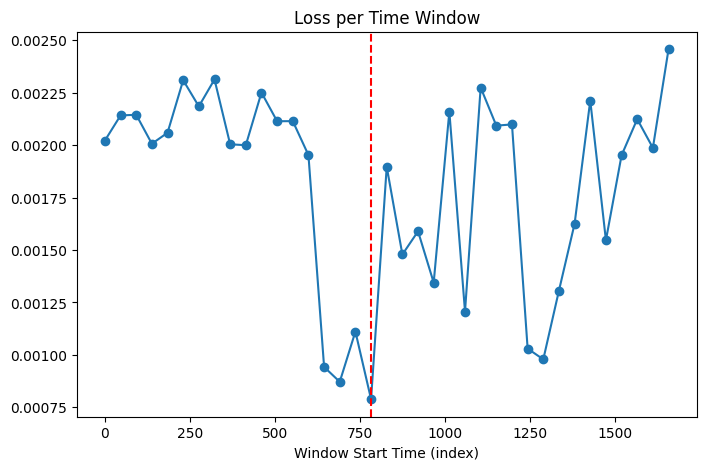

In [85]:
import numpy as np
import matplotlib.pyplot as plt
# Convert to numpy for plotting
losses = np.array(losses)
window_positions = np.array(window_positions)

# Find the most informative window (lowest loss)
best_idx = np.argmin(losses)
best_window = window_positions[best_idx]
best_loss = losses[best_idx]

print(f"\n✅ Most informative window starts at timestep {best_window}, with loss={best_loss:.6f}")

# -------------------------------
# Plot losses per window
# -------------------------------
plt.figure(figsize=(8, 5))
plt.plot(window_positions, losses, marker='o', label='Window Loss')
plt.axvline(best_window, color='r', linestyle='--', label=f'Best Window ({best_window})')
plt.title("Loss per Time Window")
plt.xlabel("Window Start Time (index)")

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Optional: fix random seed for reproducibility
np.random.seed(42)

losses = []
window_positions = []

for window in windows_sizes:
    # Slice the input (X) window
    X_window = rf_preprocessor.group_and_pad(
        rf_preprocessor.sensor_df, group_col="Experiment_ID"
    )[:, window:window + window_size, :]

    # Slice the corresponding Y segment (angle data)
    Y_window = rf_preprocessor.group_and_pad(
        rf_preprocessor.target_df, group_col="Experiment_ID"
    )[:, window:window + window_size, :]
    
    # Flatten sequences for RandomForest input
    # (since RF expects tabular data, not sequences)
    X_flat = X_window.reshape(X_window.shape[0], -1)  # (samples, features*time)
    Y_flat = Y_window.reshape(Y_window.shape[0], -1)  # (samples, targets*time or targets)

    # Split into train/test sets (simple holdout)
    n = len(X_flat)
    split = int(n * 0.8)
    X_train, X_test = X_flat[:split], X_flat[split:]
    Y_train, Y_test = Y_flat[:split], Y_flat[split:]

    # Train Random Forest
    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, Y_train)

    # Evaluate
    Y_pred = model.predict(X_test)
    mse = mean_squared_error(Y_test, Y_pred)

    losses.append(mse)
    window_positions.append(window)

    print(f"Window {window:4d} → MSE Loss = {mse:.6f}")

# Convert to numpy for plotting
losses = np.array(losses)
window_positions = np.array(window_positions)

# Find the most informative (lowest-loss) window
best_idx = np.argmin(losses)
best_window = window_positions[best_idx]
best_loss = losses[best_idx]

print(f"\n✅ Most informative window starts at timestep {best_window}, with MSE={best_loss:.6f}")

# -------------------------------
# Plot losses per window
# -------------------------------
plt.figure(figsize=(8, 5))
plt.plot(window_positions, losses, marker='o', label='Window Loss (MSE)')
plt.axvline(best_window, color='r', linestyle='--', label=f'Best Window ({best_window})')
plt.title("Random Forest - Loss per Time Window")
plt.xlabel("Window Start Time (index)")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Window    0 → MSE Loss = 0.011095
Window   46 → MSE Loss = 0.060116


ValueError: Found array with 0 feature(s) (shape=(80, 0)) while a minimum of 1 is required by RandomForestRegressor.

Detected change points: [145, 330, 425, 540, 700, 845, 940, 1125, 1310, 1410, 1743]
Most important timestamp: 304 (sample index)
Corresponding time ≈ 30.4 seconds


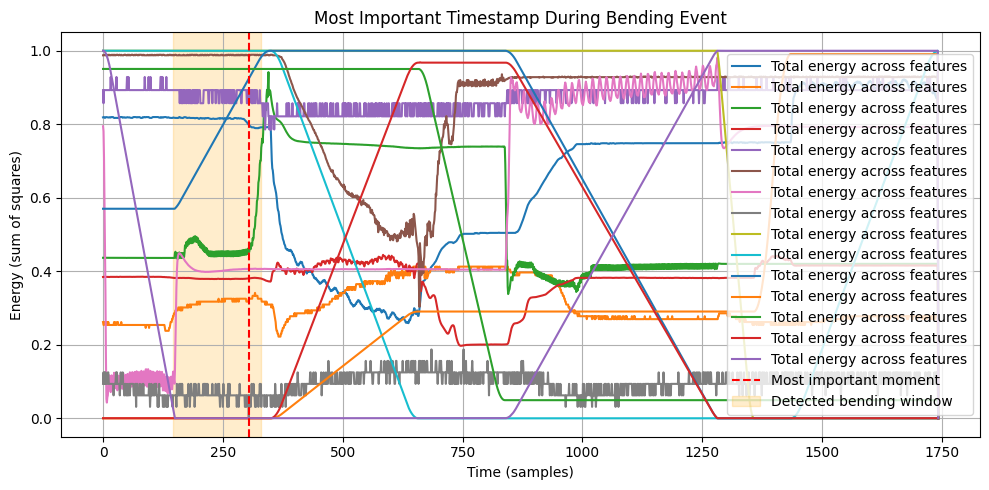